### Research credits submission

**Name :** Abhijith Sreesylesh Babu

**Paper :** *On Calibration of Modern Neural Networks*

# Calibration of the output of classification neural networks

The output of a machine learning model has to be calibrated properly. But with the advance of complex neural networks, the outputs are not calibrated.

### What is calibration?

The classification neural networks gives a category and confidence value as output. But the accuracy of the prediction is not always same as the confidence. If we take a bin of confidence interval and calculate the accuracy of the model in that interval, then we can see a gap between the accuracy and the confidence value given by the model. Calibration is a process to reduce this gap

### Approach

Some of the previous approaches tried to calibrate binary classification models:

**Histogram Binning :** Here we divide the data into bins where each bin is assigned a calibration score. Then we minimize the bin-wise loss function to find a calibrated probability for the bin

**Isotonic regression :** Here they used learning algorithm on a piecewise function to find the calibrated confidence of the model.

**Bayesian Binning into Quantiles (BBQ) :** This method is similar to Histogram binning, where they used bayesian averaging of the probabilities on the bins.

**Platt scaling :** Platt scaling is used in classification models that does not give probabilistic outputs. They use the model output in a logistic regression model to generate probabilities.

### Approaches used in this paper

In this paper, they used variations of platt scaling to calibrate multiclass classification models.

**Matrix and vector scaling :** They are muticlass variations of platt scaling, that works by applying linear transformations to the logits.

**Temperature scaling :** They are a simple variation of platt scaling in which they use a scalar T to soften the softmax function, thus calibrating it

Here I am going to try all the approaches and compare their performace based on Expected calibration error and Maximum calibration error.

I am using the ResNet model using CIFAR-10 dataset as used in the paper

In [1]:
# Importing the required libraries

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
import torch.optim as optim
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import os

In [2]:
# Fraction of the dataset used for calibration validation
calib_valid_fraction = 0.1

In [3]:
# Loading the CIFAR-10 dataset
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))  # CIFAR-10 mean/std
    ])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [4]:
# Splitting data to training and calibration validation sets

num_train = int(len(train_dataset) * (1 - calib_valid_fraction)) 
num_calib = len(train_dataset) - num_train
train_data, calib_data = torch.utils.data.random_split(train_dataset, [num_train, num_calib])

In [5]:
batch_size = 128

# Creating loaders for data
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
calib_loader = torch.utils.data.DataLoader(calib_data, batch_size=batch_size, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
# Defining the Resnet model with no pretraining
model = torchvision.models.resnet18(weights=None) 
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

In [7]:
# Using GPU if available

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [8]:
epochs = 10
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

In [9]:
# Training if model not available and saving the model to directory

model_path = "./trained_model.pth"

if os.path.exists(model_path):
    print("Loading existing model...")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
else:   
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        avg_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.3f}")
    
    torch.save(model.state_dict(), model_path)

Loading existing model...


In [10]:
# Evaluate uncalibrated model accuracy on validation and test sets
model.eval()
def evaluate(loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [11]:
# Calculating the accuracy before calibration

val_accuracy = evaluate(calib_loader)
test_accuracy = evaluate(test_loader)
print(f"Validation Accuracy (uncalibrated): {val_accuracy*100:.2f}%")
print(f"Test Accuracy (uncalibrated): {test_accuracy*100:.2f}%")

Validation Accuracy (uncalibrated): 88.70%
Test Accuracy (uncalibrated): 70.94%


In [12]:
# function to compute ECE and MCE
def compute_ece_and_mce(confidences, correct, M=15):
    """Compute Expected Calibration Error (ECE) with M bins."""
    confidences = np.asarray(confidences)
    correct = np.asarray(correct)
    N = len(confidences)
    bin_size = 1.0 / M
    ece = 0.0
    mce = 0.0
    for m in range(M):
        # bin range [m/M, (m+1)/M)
        start = m * bin_size
        end = (m+1) * bin_size if m < M-1 else 1.0  # last bin inclusive of 1.0
        in_bin = (confidences >= start) & (confidences < end) if m < M-1 else (confidences >= start) & (confidences <= end)
        bin_count = np.sum(in_bin)
        if bin_count > 0:
            bin_acc = np.mean(correct[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            gap = abs(bin_acc - bin_conf)
            ece += (bin_count / N) * gap
            mce = max(mce, gap)
    return ece, mce

In [13]:
# Calculate ECE and MCE for uncalibrated model

val_confidences = []
val_correct = []
test_confidences = []
test_correct = []

with torch.no_grad():
    for images, labels in calib_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)
        # Move data to CPU and numpy
        max_probs = max_probs.cpu().numpy()
        preds = preds.cpu().numpy()
        labels = labels.numpy()
        val_confidences.extend(max_probs)
        val_correct.extend(preds == labels)

    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)
        max_probs = max_probs.cpu().numpy()
        preds = preds.cpu().numpy()
        labels = labels.numpy()
        test_confidences.extend(max_probs)
        test_correct.extend(preds == labels)

uncalib_ece, uncalib_mce = compute_ece_and_mce(test_confidences, test_correct, M=15)
print(f"Uncalibrated ECE: {uncalib_ece:.4f}, MCE: {uncalib_mce:.4f}")

Uncalibrated ECE: 0.1166, MCE: 0.2041


In [14]:
# Collect logits, probabilities, and labels from the validation set for calibration

val_logits_list = []
val_probs_list = []
val_labels_list = []
val_preds_list = []

model.eval()
with torch.no_grad():
    for images, labels in calib_loader:
        images = images.to(device)
        logits = model(images) 
        probs = F.softmax(logits, dim=1) 
        preds = torch.argmax(logits, dim=1) 
        val_logits_list.append(logits.cpu().numpy())
        val_probs_list.append(probs.cpu().numpy())
        val_labels_list.append(labels.numpy())
        val_preds_list.append(preds.cpu().numpy())

val_logits = np.vstack(val_logits_list)
val_probs = np.vstack(val_probs_list)
val_labels = np.concatenate(val_labels_list)
val_preds = np.concatenate(val_preds_list)
val_confidences = np.max(val_probs, axis=1)
val_correct = (val_preds == val_labels).astype(float)

In [15]:
# Function for temperature scaling

def calibrate_temperature(val_logits, val_labels):
    logits_tensor = torch.tensor(val_logits, dtype=torch.float32, device=device)
    labels_tensor = torch.tensor(val_labels, dtype=torch.long, device=device)
    T = torch.tensor([1.0], dtype=torch.float32, device=device, requires_grad=True)
    optimizer = optim.LBFGS([T], lr=0.5, max_iter=50) 
    def eval_loss():
        optimizer.zero_grad()
        scaled_logits = logits_tensor / T.clamp(min=1e-6)
        loss = F.cross_entropy(scaled_logits, labels_tensor)
        loss.backward()
        return loss
    optimizer.step(eval_loss)
    T_opt = T.item()
    print(f"Optimal temperature: {T_opt:.3f}")
    def apply(logits):
        logits = torch.tensor(logits, dtype=torch.float32)
        probs = F.softmax(logits / T_opt, dim=1).numpy()
        return np.max(probs, axis=1)
    return apply, T_opt

In [16]:
# Fit temperature scaling on validation logits
temp_calibrator, temperature = calibrate_temperature(val_logits, val_labels)

Optimal temperature: 0.947


In [17]:
test_logits_list = []
test_labels_list = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        test_logits_list.append(logits.cpu().numpy())
        test_labels_list.append(labels.numpy())
test_logits = np.vstack(test_logits_list)
test_labels = np.concatenate(test_labels_list)
temp_calib_conf = temp_calibrator(test_logits)
temp_ece, temp_mce = compute_ece_and_mce(temp_calib_conf, test_correct, M=15)
print(f"Temperature Scaling ECE: {temp_ece:.4f}, MCE: {temp_mce:.4f}")

Temperature Scaling ECE: 0.1255, MCE: 0.2330


In [18]:
def calibrate_vector(val_logits, val_labels):
    K = val_logits.shape[1]
    logits_tensor = torch.tensor(val_logits, dtype=torch.float32, device=device)
    labels_tensor = torch.tensor(val_labels, dtype=torch.long, device=device)
    scale = torch.ones(K, dtype=torch.float32, device=device, requires_grad=True)
    bias  = torch.zeros(K, dtype=torch.float32, device=device, requires_grad=True)
    optimizer = optim.LBFGS([scale, bias], lr=0.1, max_iter=100)
    def eval_loss_vec():
        optimizer.zero_grad()
        scaled_logits = logits_tensor * scale + bias
        loss = F.cross_entropy(scaled_logits, labels_tensor)
        loss.backward()
        return loss

    optimizer.step(eval_loss_vec)
    scale_opt = scale.detach().cpu().numpy()
    bias_opt = bias.detach().cpu().numpy()
    def apply(logits):
        logits = np.array(logits, dtype=np.float32)
        scaled = logits * scale_opt + bias_opt
        probs = softmax(scaled)
        return np.max(probs, axis=1)
    def softmax(z):
        z = z - np.max(z, axis=1, keepdims=True) 
        expz = np.exp(z)
        return expz / np.sum(expz, axis=1, keepdims=True)
    return apply, scale_opt, bias_opt


In [19]:
vector_calibrator, scale_vec, bias_vec = calibrate_vector(val_logits, val_labels)
vector_calib_conf = vector_calibrator(test_logits)
vector_ece, vector_mce = compute_ece_and_mce(vector_calib_conf, test_correct, M=15)
print(f"Vector Scaling ECE: {vector_ece:.4f}, MCE: {vector_mce:.4f}")

Vector Scaling ECE: 0.1273, MCE: 0.2415


In [20]:
def calibrate_matrix(val_logits, val_labels):
    K = val_logits.shape[1]
    logits_tensor = torch.tensor(val_logits, dtype=torch.float32, device=device)
    labels_tensor = torch.tensor(val_labels, dtype=torch.long, device=device)
    # Initialize weight matrix and bias
    W = torch.eye(K, dtype=torch.float32, device=device, requires_grad=True)  # start as identity
    b = torch.zeros(K, dtype=torch.float32, device=device, requires_grad=True)
    optimizer = optim.LBFGS([W, b], lr=0.1, max_iter=100)

    def eval_loss_mat():
        optimizer.zero_grad()
        # W is KxK, logits_tensor is NxK -> output NxK
        scaled_logits = logits_tensor @ W.t() + b  # (apply linear transform)
        loss = F.cross_entropy(scaled_logits, labels_tensor)
        loss.backward()
        return loss

    optimizer.step(eval_loss_mat)
    W_opt = W.detach().cpu().numpy()
    b_opt = b.detach().cpu().numpy()
    # Calibration function
    def apply(logits):
        logits = np.array(logits, dtype=np.float32)
        scaled = logits.dot(W_opt.T) + b_opt
        # softmax and return max confidence
        expz = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))
        probs = expz / np.sum(expz, axis=1, keepdims=True)
        return np.max(probs, axis=1)
    return apply, W_opt, b_opt

In [21]:
# Fit matrix scaling on validation logits
matrix_calibrator, W_mat, b_mat = calibrate_matrix(val_logits, val_labels)
# Apply to test logits
matrix_calib_conf = matrix_calibrator(test_logits)
matrix_ece, matrix_mce = compute_ece_and_mce(matrix_calib_conf, test_correct, M=15)
print(f"Matrix Scaling ECE: {matrix_ece:.4f}, MCE: {matrix_mce:.4f}")

Matrix Scaling ECE: 0.1345, MCE: 0.2494


In [22]:
methods = ["Uncalibrated", "Temperature Scaling", "Vector Scaling", "Matrix Scaling"]
ece_values = [uncalib_ece, temp_ece, vector_ece, matrix_ece]
mce_values = [uncalib_mce, temp_mce, vector_mce, matrix_mce]

for method, ece, mce in zip(methods, ece_values, mce_values):
    print(f"{method:20s}: ECE = {ece:.3%}, MCE = {mce:.3%}")

Uncalibrated        : ECE = 11.657%, MCE = 20.410%
Temperature Scaling : ECE = 12.551%, MCE = 23.302%
Vector Scaling      : ECE = 12.730%, MCE = 24.149%
Matrix Scaling      : ECE = 13.449%, MCE = 24.939%


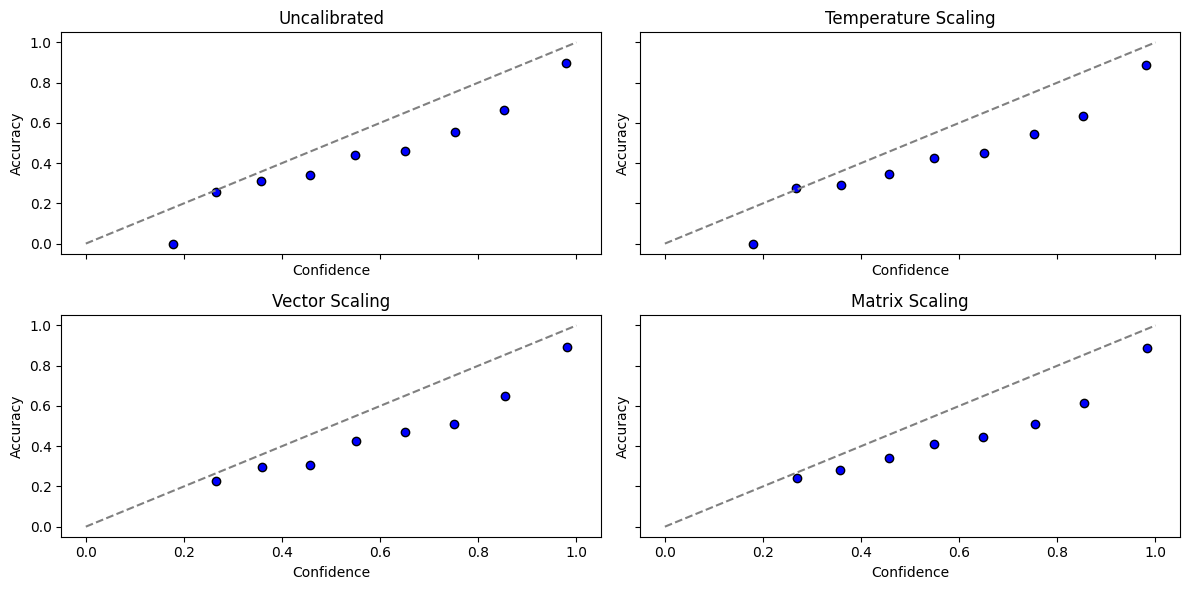

In [23]:
# Use 10 bins for visualization clarity
vis_bins = 10
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.flatten()
for ax, method, calib_conf in zip(axes, methods, 
                                  [test_confidences, temp_calib_conf, vector_calib_conf, matrix_calib_conf]):
    # Compute bin stats
    conf = np.array(calib_conf)
    corr = np.array(test_correct)
    bin_indices = np.floor(conf * vis_bins).astype(int)
    bin_indices = np.clip(bin_indices, 0, vis_bins-1)
    bin_acc = np.zeros(vis_bins)
    bin_conf = np.zeros(vis_bins)
    bin_count = np.zeros(vis_bins)
    for i in range(vis_bins):
        mask = (bin_indices == i)
        if np.sum(mask) > 0:
            bin_acc[i] = np.mean(corr[mask])
            bin_conf[i] = np.mean(conf[mask])
            bin_count[i] = np.sum(mask)
        else:
            bin_acc[i] = np.nan
            bin_conf[i] = (i + 0.5) / vis_bins
    ax.plot([0,1], [0,1], "--", color="gray") 
    ax.scatter(bin_conf, bin_acc, c="b", edgecolors="k")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(method)
plt.tight_layout()
plt.show()

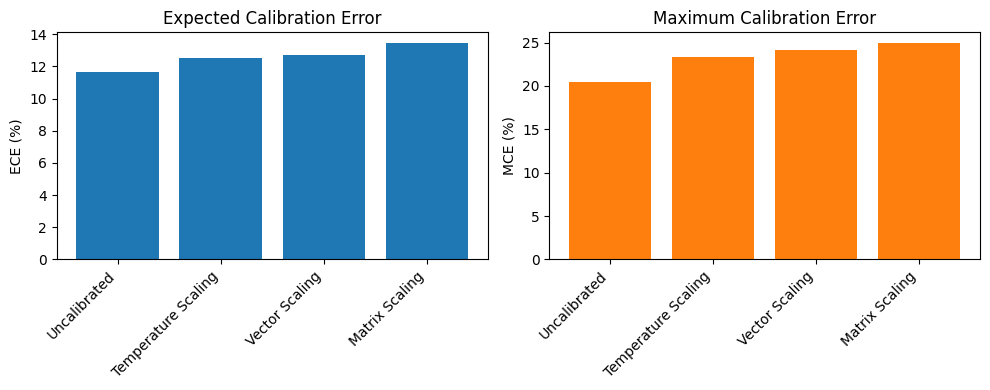

In [24]:
# Bar plot for ECE and MCE
x = np.arange(len(methods))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.bar(x, [e*100 for e in ece_values], color="C0")
ax1.set_xticks(x); ax1.set_xticklabels(methods, rotation=45, ha="right")
ax1.set_ylabel("ECE (%)")
ax1.set_title("Expected Calibration Error")

ax2.bar(x, [m*100 for m in mce_values], color="C1")
ax2.set_xticks(x); ax2.set_xticklabels(methods, rotation=45, ha="right")
ax2.set_ylabel("MCE (%)")
ax2.set_title("Maximum Calibration Error")
plt.tight_layout()
plt.show()